# GeoDiff 3x Strong Base and routed experts on official OLI2MSI

This isolated Kaggle notebook trains the current `3x-continued` architecture on
real cross-sensor OLI2MSI pairs:

```text
Landsat-8 OLI RGB, 30 m, 3 × 160 × 160
                     → GeoDiff-GAN SR-3x
Sentinel-2 MSI RGB, 10 m, 3 × 480 × 480
```

Full runs require the official `5,225` training and `100` test pairs. A stable
source-ID hash reserves 10% of the official training set for validation; the
official test set is never used for selection. Full frames are stored and used
for validation/test. Random `32→96`, `64→192`, and `128→384` aligned crops are
used only during base training.

The notebook compares the final frozen base with a one-expert control, generic
MoE, and reliability-supervised MoE. It uses fixed OLI2MSI radiometry,
resize-convolution, no PixelShuffle, no captions, no synthetic LR, no GAN loss,
and no natural-image perceptual loss. The default full training budget is about
285 minutes plus preprocessing and evaluation. Run the smoke profile first, then
use a new suite root with `FAST_DEV_RUN=False`.

Attach the official OLI2MSI data and `geodiff_oli2msi_strong_base_source.zip` as
private Kaggle datasets. A 35 dB result is a target, not a guarantee.

## Before you run

In [1]:
from pathlib import Path
import os, sys, json, subprocess, time, shutil, hashlib
from collections import Counter

FAST_DEV_RUN = False
REPOSITORY_BRANCH = "3x-continued"
REPOSITORY_URL = "https://github.com/shashankjs2002/SI-SR-1.git"
REPOSITORY_DIR = Path("/kaggle/working/geodiff-3x-continued-oli2msi")
SOURCE_ARCHIVE = None
SUITE_ROOT = Path(
    "/kaggle/working/geodiff-oli2msi-strong-smoke"
    if FAST_DEV_RUN else "/kaggle/working/geodiff-oli2msi-strong-v1"
)
# OLI2MSI_DATA_ROOT = None  # Set only when auto-discovery finds multiple layouts.
OLI2MSI_DATA_ROOT = Path(
    "/kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI"
)
RESTORE_SUITE_FROM = None

DATA_PROTOCOL_ID = "oli2msi_official_full160_clip03_uint8grid_v1"
VALIDATION_PERCENT = 5
BENCHMARK_REFLECTANCE_MAX = 0.3
QUANTIZE_TO_UINT8_GRID = True
MINIMUM_VALID_FRACTION = 0.99
LR_FRAME_SIZE, SCALE = 160, 3
HR_FRAME_SIZE = LR_FRAME_SIZE * SCALE
MAX_TRAIN_SOURCE_PAIRS = 64 if FAST_DEV_RUN else None
MAX_VALIDATION_SOURCE_PAIRS = 16 if FAST_DEV_RUN else None
MAX_TEST_SOURCE_PAIRS = 16 if FAST_DEV_RUN else None

NUM_EXPERTS = 4
TOP_K = 1
INCLUDE_MULTISPECTRAL = False
NEW_MULTISPECTRAL = False
TRAIN_LR_CROP = 64
BASE_PHASES = (
    {"name": "crop32", "crop": 32, "epochs": 30, "minutes": 60,
     "learning_rate": 1e-4, "max_batches": 400},
    {"name": "crop64", "crop": 64, "epochs": 24, "minutes": 60,
     "learning_rate": 5e-5, "max_batches": 180},
    {"name": "crop128", "crop": 128, "epochs": 16, "minutes": 30,
     "learning_rate": 1e-5, "max_batches": 60},
)
EPOCHS = {"base": 20, "vae": 20, "diffusion": 12, "joint": 8}
SHARED_MINUTES = {"base": 40, "vae": 40}
PER_EXPERIMENT_MINUTES = {"diffusion": 40, "joint": 40}
RUN_EARLIER = {name: False for name in (
    "rgb_standard", "rgb_fidelity", "multispectral_fidelity",
    "rgb_harmonized_fidelity", "multispectral_guided_fidelity")}

BASE_VALIDATION_LIMIT = 4 if FAST_DEV_RUN else 100
RESIDUAL_VALIDATION_LIMIT = 4 if FAST_DEV_RUN else 32
ALIGNMENT_AUDIT_LIMIT = 4 if FAST_DEV_RUN else 100
EVAL_LIMIT = 4 if FAST_DEV_RUN else 100
TEST_EVAL_LIMIT = 4 if FAST_DEV_RUN else 100
EVAL_SAMPLES = 1 if FAST_DEV_RUN else 4
EVAL_STEPS = 2 if FAST_DEV_RUN else 20
RUN_TEST_EVALUATION = True
RANDOM_SEED = 42

if not 1 <= TOP_K <= NUM_EXPERTS:
    raise ValueError("Require 1 <= TOP_K <= NUM_EXPERTS")
SUITE_ROOT.mkdir(parents=True, exist_ok=True)
DATA_ROOT = SUITE_ROOT / "dataset"
DOWNLOAD_ROOT = SUITE_ROOT / "official_download"
PATCH_ROOT = DATA_ROOT / "patches"
MANIFEST = DATA_ROOT / "manifest.jsonl"
QUARANTINE_LOG = DATA_ROOT / "quarantine.jsonl"
EXPERIMENT_ROOT = SUITE_ROOT / "experiments"
FIGURE_ROOT = SUITE_ROOT / "figures"
for directory in (DATA_ROOT, DOWNLOAD_ROOT, PATCH_ROOT, EXPERIMENT_ROOT, FIGURE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

def run(command, cwd=None):
    command = list(map(str, command))
    environment = os.environ.copy()
    environment["PYTHONPATH"] = str(REPOSITORY_DIR / "src") + os.pathsep + environment.get("PYTHONPATH", "")
    environment["PYTHONUNBUFFERED"] = "1"
    print("+", " ".join(command), flush=True)
    return subprocess.run(command, cwd=cwd, env=environment, check=True)

main_minutes = sum(phase["minutes"] for phase in BASE_PHASES)
main_minutes += SHARED_MINUTES["vae"] + 3 * sum(PER_EXPERIMENT_MINUTES.values())
print("Suite:", SUITE_ROOT)
print("Protocol:", LR_FRAME_SIZE, "->", HR_FRAME_SIZE, "at", SCALE, "x")
print("Nominal main-study training budget:", main_minutes, "minutes")


Suite: /kaggle/working/geodiff-oli2msi-strong-v1
Protocol: 160 -> 480 at 3 x
Nominal main-study training budget: 430 minutes


## 1. Install the exact source snapshot and verify the GPU

In [2]:
import zipfile, tarfile, hashlib

def extract_safely(archive, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    def safe(name):
        path = (destination / name).resolve()
        if not path.is_relative_to(destination):
            raise ValueError(f"Unsafe archive member: {name}")
    if zipfile.is_zipfile(archive):
        with zipfile.ZipFile(archive) as z:
            required = sum(entry.file_size for entry in z.infolist())
            if required + 2 * 2**30 > shutil.disk_usage(destination).free:
                raise RuntimeError("Insufficient scratch space to unpack this archive. Attach already-extracted products as a Kaggle input dataset; no files were deleted.")
            for entry in z.infolist():
                safe(entry.filename)
                if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                    raise ValueError("Archive symlinks are not accepted")
            z.extractall(destination)
    else:
        with tarfile.open(archive) as t:
            required = sum(entry.size for entry in t.getmembers() if entry.isfile())
            if required + 2 * 2**30 > shutil.disk_usage(destination).free:
                raise RuntimeError("Insufficient scratch space. Attach extracted products as read-only Kaggle input; no files were deleted.")
            for entry in t.getmembers():
                safe(entry.name)
                if not (entry.isfile() or entry.isdir()):
                    raise ValueError("Only regular files/directories may be extracted")
            t.extractall(destination, filter="data")

archives = ([Path(SOURCE_ARCHIVE)] if SOURCE_ARCHIVE else
            list(Path("/kaggle/input").rglob("geodiff_oli2msi_strong_base_source*.zip")))
if len(archives) > 1:
    raise RuntimeError("Set SOURCE_ARCHIVE to exactly one attached source snapshot")
if not REPOSITORY_DIR.exists():
    if archives:
        extract_safely(archives[0], REPOSITORY_DIR)
    else:
        run(["git", "clone", "--depth", 1, "--branch", REPOSITORY_BRANCH,
             REPOSITORY_URL, REPOSITORY_DIR])
elif (REPOSITORY_DIR / ".git").is_dir():
    branch = subprocess.check_output(["git", "branch", "--show-current"], cwd=REPOSITORY_DIR, text=True).strip()
    if branch != REPOSITORY_BRANCH:
        raise RuntimeError(f"Wrong branch {branch}; choose a new clone directory. No automatic checkout.")
if archives:
    with zipfile.ZipFile(archives[0]) as archive:
        for entry in archive.infolist():
            if not entry.is_dir():
                path = REPOSITORY_DIR / entry.filename
                if not path.is_file() or hashlib.sha256(path.read_bytes()).digest() != hashlib.sha256(archive.read(entry)).digest():
                    raise RuntimeError("The existing source tree differs from the attached snapshot. Choose a new REPOSITORY_DIR; nothing was overwritten.")
required = REPOSITORY_DIR / "src/geodiff_gan/experiments/tile_moe.py"
if not required.is_file():
    raise RuntimeError("This source lacks the strong-base experiment helpers. Attach the supplied source ZIP and use a new REPOSITORY_DIR.")
run([sys.executable, "-m", "pip", "install", "-q", "numpy", "Pillow>=10", "PyYAML>=6",
     "tqdm>=4.66", "rasterio>=1.3", "pandas", "matplotlib"])
run([sys.executable, "-m", "pip", "install", "-q", "-e", REPOSITORY_DIR, "--no-deps"])
sys.path.insert(0, str(REPOSITORY_DIR / "src"))
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.nn import functional as F
from IPython.display import display
from geodiff_gan.experiments.tile_moe import (
    sha256, lock_json, snapshot_manifest, balanced_manifest, experiment_config, run_stage,
    LEGACY_PROFILES, NEW_PROFILES,
)
from geodiff_gan.models.system import GeoDiffGAN
print(sys.version, torch.__version__, "CUDA", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("Enable a Kaggle GPU. Do not reinstall CUDA/PyTorch or change the host driver.")
print(torch.cuda.get_device_name(0))
source_files = sorted((REPOSITORY_DIR / "src/geodiff_gan").rglob("*.py"))
source_digest = hashlib.sha256("".join(str(p.relative_to(REPOSITORY_DIR)) + sha256(p) for p in source_files).encode()).hexdigest()
lock_json(SUITE_ROOT / "source_lock.json", {"source_sha256": source_digest, "branch": REPOSITORY_BRANCH})


+ /usr/bin/python3 -m pip install -q numpy Pillow>=10 PyYAML>=6 tqdm>=4.66 rasterio>=1.3 pandas matplotlib
+ /usr/bin/python3 -m pip install -q -e /kaggle/working/geodiff-3x-continued-oli2msi --no-deps
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0] 2.10.0+cu128 CUDA True
Tesla T4


## 2. Restore this notebook's saved session artifacts (optional)

In [3]:
if RESTORE_SUITE_FROM:
    source = Path(RESTORE_SUITE_FROM).resolve()
    if source.name != SUITE_ROOT.name:
        raise ValueError("Restore to the SAME suite directory name for checkpoint/config lineage")
    for item in source.rglob("*"):
        if item.is_file() and "extracted_inputs" not in item.relative_to(source).parts:
            target = SUITE_ROOT / item.relative_to(source)
            if target.exists() and sha256(target) != sha256(item):
                raise RuntimeError(f"Restore conflict: {target}; nothing overwritten")
            if not target.exists():
                target.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(item, target)
    print("Restored checkpoints and prepared NPZs. Paths must match the original SUITE_ROOT.")
else:
    print("Fresh/current session; restore skipped")


Fresh/current session; restore skipped


## 3. Locate the official OLI2MSI folders

Attach a Kaggle dataset containing `train_lr`, `train_hr`, `test_lr`, and
`test_hr`. The notebook also accepts an OLI2MSI-named ZIP and extracts it safely
into this suite. It does not use Google Drive because public quota failures can
silently leave unmatched partial data. No attached file is modified or deleted.

In [4]:
search_roots = [Path(OLI2MSI_DATA_ROOT)] if OLI2MSI_DATA_ROOT is not None else []
search_roots += [Path("/kaggle/input"), DOWNLOAD_ROOT]

for root in list(search_roots):
    if not root.exists():
        continue
    for archive in root.rglob("*.zip"):
        if "oli2msi" not in archive.name.casefold():
            continue
        with zipfile.ZipFile(archive) as handle:
            groups = {
                part.casefold()
                for member in handle.namelist()
                for part in Path(member).parts
                if part.casefold() in {"train_lr", "train_hr", "test_lr", "test_hr"}
            }
        if groups != {"train_lr", "train_hr", "test_lr", "test_hr"}:
            continue
        destination = DOWNLOAD_ROOT / archive.stem
        marker = destination / ".extraction_complete"
        if not marker.exists():
            print("Extracting", archive)
            extract_safely(archive, destination)
            marker.write_text(str(archive), encoding="utf-8")

def contains_tiffs(path):
    return path.is_dir() and any(
        item.is_file() and item.suffix.casefold() in (".tif", ".tiff")
        for item in path.iterdir()
    )

def discover_layout(roots):
    print(roots)
    required = ("train_lr", "train_hr", "test_lr", "test_hr")
    layouts = []
    for root in roots:
        if not root.exists():
            continue
        candidates = [root] + [path.parent for path in root.rglob("train_lr") if path.is_dir()]
        for candidate in candidates:
            layout = {name: candidate / name for name in required}
            if all(contains_tiffs(path) for path in layout.values()):
                resolved = candidate.resolve()
                if all(resolved != existing[0] for existing in layouts):
                    layouts.append((resolved, layout))
    return layouts

layouts = discover_layout(search_roots)
if len(layouts) != 1:
    summary = [(str(root), {name: sum(1 for item in path.iterdir() if item.suffix.casefold() in (".tif", ".tiff",".TIF", "TIFF"))
                            for name, path in layout.items()}) for root, layout in layouts]
    raise RuntimeError(
        f"Expected exactly one complete OLI2MSI layout, found {len(layouts)}: {summary}. "
        "Set OLI2MSI_DATA_ROOT to the intended dataset root."
    )
OLI2MSI_ROOT, DATA_DIRS = layouts[0]
print("OLI2MSI root:", OLI2MSI_ROOT)
for name, path in DATA_DIRS.items():
    count = sum(1 for item in path.iterdir() if item.suffix.casefold() in (".tif", ".tiff"))
    print(name, count, path)


[PosixPath('/kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI'), PosixPath('/kaggle/input'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/official_download')]
OLI2MSI root: /kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI
train_lr 5225 /kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI/train_lr
train_hr 5225 /kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI/train_hr
test_lr 100 /kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI/test_lr
test_hr 100 /kaggle/input/datasets/twilight2002/oli2msi-thesis/OLI2MSI-dataset/OLI2MSI/test_hr


## 4. Audit pairs and prepare restart-safe full-frame NPZ files

Both sensors receive the same fixed official transformation:
`clip(reflectance, 0, 0.3) / 0.3`. With `QUANTIZE_TO_UINT8_GRID=True`, values
are also placed on the 8-bit grid used by the official PNG conversion. There is
no per-image normalization, target-time calibration, synthetic degradation, or
cropping during preprocessing. Corrupt and unpaired files are quarantined.

In [5]:
import rasterio
from tqdm.auto import tqdm
from geodiff_gan.data.manifest import ManifestRecord, load_manifest, write_manifest
from geodiff_gan.experiments.tile_moe import balanced_manifest

lock_json(DATA_ROOT / "protocol_lock.json", {
    "protocol": DATA_PROTOCOL_ID, "validation_percent": VALIDATION_PERCENT,
    "reflectance_max": BENCHMARK_REFLECTANCE_MAX,
    "quantize_uint8_grid": QUANTIZE_TO_UINT8_GRID,
    "lr_frame": LR_FRAME_SIZE, "scale": SCALE, "seed": RANDOM_SEED,
    "fast_dev": FAST_DEV_RUN,
})

def index_tiffs(directory):
    indexed = {}
    for path in directory.iterdir():
        if path.is_file() and path.suffix.casefold() in (".tif", ".tiff"):
            key = path.stem.casefold()
            if key in indexed:
                raise RuntimeError(f"Duplicate TIFF stem {path.stem!r} in {directory}")
            indexed[key] = path
    return indexed

def pair_directories(lr_directory, hr_directory):
    lr_files, hr_files = index_tiffs(lr_directory), index_tiffs(hr_directory)
    common = sorted(lr_files.keys() & hr_files.keys())
    return ([(key, lr_files[key], hr_files[key]) for key in common],
            sorted(lr_files.keys() - hr_files.keys()),
            sorted(hr_files.keys() - lr_files.keys()))

official_train_pairs, train_missing_hr, train_missing_lr = pair_directories(DATA_DIRS["train_lr"], DATA_DIRS["train_hr"])
official_test_pairs, test_missing_hr, test_missing_lr = pair_directories(DATA_DIRS["test_lr"], DATA_DIRS["test_hr"])
print("Official paired counts:", len(official_train_pairs), len(official_test_pairs))
missing = {"train_missing_hr": train_missing_hr, "train_missing_lr": train_missing_lr,
           "test_missing_hr": test_missing_hr, "test_missing_lr": test_missing_lr}
if any(missing.values()):
    with QUARANTINE_LOG.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps({"stage": "pair_audit", **missing}) + "\n")
    print("Unpaired files quarantined:", {key: len(items) for key, items in missing.items()})
if not FAST_DEV_RUN and (len(official_train_pairs) != 5225 or len(official_test_pairs) != 100):
    raise RuntimeError("Publication run requires exactly 5,225 official train and 100 official test pairs")

def source_split(key):
    bucket = int(hashlib.sha256(key.encode()).hexdigest()[:8], 16) % 100
    return "val" if bucket < VALIDATION_PERCENT else "train"

train_pairs = [pair for pair in official_train_pairs if source_split(pair[0]) == "train"]
val_pairs = [pair for pair in official_train_pairs if source_split(pair[0]) == "val"]
test_pairs = official_test_pairs
def truncate(items, maximum):
    return items if maximum is None else items[:int(maximum)]
train_pairs = truncate(train_pairs, MAX_TRAIN_SOURCE_PAIRS)
val_pairs = truncate(val_pairs, MAX_VALIDATION_SOURCE_PAIRS)
test_pairs = truncate(test_pairs, MAX_TEST_SOURCE_PAIRS)
selected = {"train": train_pairs, "val": val_pairs, "test": test_pairs}
print("Selected source pairs:", {split: len(items) for split, items in selected.items()})
if not FAST_DEV_RUN and shutil.disk_usage(SUITE_ROOT).free < 8 * 2**30:
    raise RuntimeError(
        "Less than 8 GiB remains in Kaggle working storage. Attach an already-prepared "
        "suite or free only disposable session artifacts; this notebook deletes nothing."
    )
split_keys = {split: {item[0] for item in items} for split, items in selected.items()}
if any(split_keys[left] & split_keys[right] for left, right in (("train", "val"), ("train", "test"), ("val", "test"))):
    raise RuntimeError("Source leakage detected")

audit_paths = [path for _, lr, hr in (train_pairs + val_pairs + test_pairs)[:8] for path in (lr, hr)]
p99_values = []
for path in audit_paths:
    with rasterio.open(path) as source:
        p99_values.append(float(np.nanpercentile(source.read([1, 2, 3], out_dtype="float32"), 99)))
global_p99 = max(p99_values)
REFLECTANCE_DIVISOR = 1.0 if global_p99 <= 1.5 else 10000.0 if global_p99 <= 12000 else None
if REFLECTANCE_DIVISOR is None:
    raise RuntimeError(f"Unsupported OLI2MSI value range: p99={global_p99}")
print("Dataset-level reflectance divisor:", REFLECTANCE_DIVISOR)

def read_rgb(path, expected_size):
    with rasterio.open(path) as source:
        if source.count < 3 or (source.height, source.width) != (expected_size, expected_size):
            raise ValueError(f"Unexpected raster geometry: {path} bands={source.count} shape={(source.height, source.width)}")
        image = source.read([1, 2, 3], out_dtype="float32") / REFLECTANCE_DIVISOR
        valid = (source.read_masks([1, 2, 3]) > 0).all(0) & np.isfinite(image).all(0)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    image = np.clip(image, 0, BENCHMARK_REFLECTANCE_MAX) / BENCHMARK_REFLECTANCE_MAX
    if QUANTIZE_TO_UINT8_GRID:
        image = np.round(image * 255.0) / 255.0
    return image, valid

selected_keys = {f"{split}:{key}" for split, items in selected.items() for key, _, _ in items}
loaded = load_manifest(MANIFEST) if MANIFEST.exists() else []
records_by_key = {record.source_product: record for record in loaded
                  if record.source_product in selected_keys and record.source == DATA_PROTOCOL_ID
                  and Path(record.patch).exists()}

def quarantine(payload):
    with QUARANTINE_LOG.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(payload, ensure_ascii=True) + "\n")

status = Counter()
for split, items in selected.items():
    for key, lr_path, hr_path in tqdm(items, desc=f"prepare {split}", unit="pair"):
        record_key = f"{split}:{key}"
        if record_key in records_by_key:
            status["skipped"] += 1
            continue
        try:
            lr, valid_lr = read_rgb(lr_path, LR_FRAME_SIZE)
            hr, valid_hr = read_rgb(hr_path, HR_FRAME_SIZE)
            valid_fraction = min(float(valid_lr.mean()), float(valid_hr.mean()))
            if valid_fraction < MINIMUM_VALID_FRACTION:
                raise ValueError(f"valid_fraction={valid_fraction:.6f}")
            directory = PATCH_ROOT / split
            directory.mkdir(parents=True, exist_ok=True)
            patch = directory / f"{key}.npz"
            temporary = patch.with_suffix(".npz.tmp")
            with temporary.open("wb") as handle:
                np.savez_compressed(handle, lr=lr.astype(np.float16), clean_lr=lr.astype(np.float16),
                    hr=hr.astype(np.float16), valid_mask_lr=valid_lr[None].astype(np.uint8),
                    valid_mask_hr=valid_hr[None].astype(np.uint8),
                    degradation=np.array([0.5, 0, 0, 0], dtype=np.float32))
            temporary.replace(patch)
            records_by_key[record_key] = ManifestRecord(
                patch=str(patch.resolve()), tile_id=key, split=split, row=0, col=0,
                valid_fraction=valid_fraction, source=DATA_PROTOCOL_ID,
                license_id="see-official-OLI2MSI-distribution", source_product=record_key,
                landsat_product=lr_path.name, sentinel_product=hr_path.name,
                day_gap=0, scale=SCALE,
            )
            status["written"] += 1
        except Exception as error:
            status["quarantined"] += 1
            quarantine({"split": split, "key": key, "lr": str(lr_path), "hr": str(hr_path),
                        "error": f"{type(error).__name__}: {error}"})
        if (status["written"] + status["quarantined"]) % 50 == 0:
            write_manifest(MANIFEST, sorted(records_by_key.values(), key=lambda item: (item.split, item.tile_id)))

write_manifest(MANIFEST, sorted(records_by_key.values(), key=lambda item: (item.split, item.tile_id)))
records = load_manifest(MANIFEST)
if {record.source_product for record in records} != selected_keys:
    raise RuntimeError("Prepared manifest does not exactly match selected source pairs; inspect quarantine log")
split_counts = Counter(record.split for record in records)
print("Preparation:", dict(status), "manifest:", dict(split_counts))
lock_json(DATA_ROOT / "manifest_lock.json", {"sha256": sha256(MANIFEST), "records": len(records)})
MANIFEST = balanced_manifest(MANIFEST, DATA_ROOT / "balanced_manifest.jsonl", RANDOM_SEED)
records = load_manifest(MANIFEST)
print("Frozen balanced manifest:", MANIFEST, sha256(MANIFEST))


Official paired counts: 5225 100
Selected source pairs: {'train': 4951, 'val': 274, 'test': 100}
Dataset-level reflectance divisor: 1.0


prepare train:   0%|          | 0/4951 [00:00<?, ?pair/s]

prepare val:   0%|          | 0/274 [00:00<?, ?pair/s]

prepare test:   0%|          | 0/100 [00:00<?, ?pair/s]

Preparation: {'skipped': 5325} manifest: {'test': 100, 'train': 4951, 'val': 274}
Frozen balanced manifest: /kaggle/working/geodiff-oli2msi-strong-v1/dataset/balanced_manifest.jsonl 15e3ac081662a7fe2cfddd548f4294a5b0c6c2994f0efa1094c48ed7d1026060


## 5. Inspect an actual full-frame OLI2MSI pair

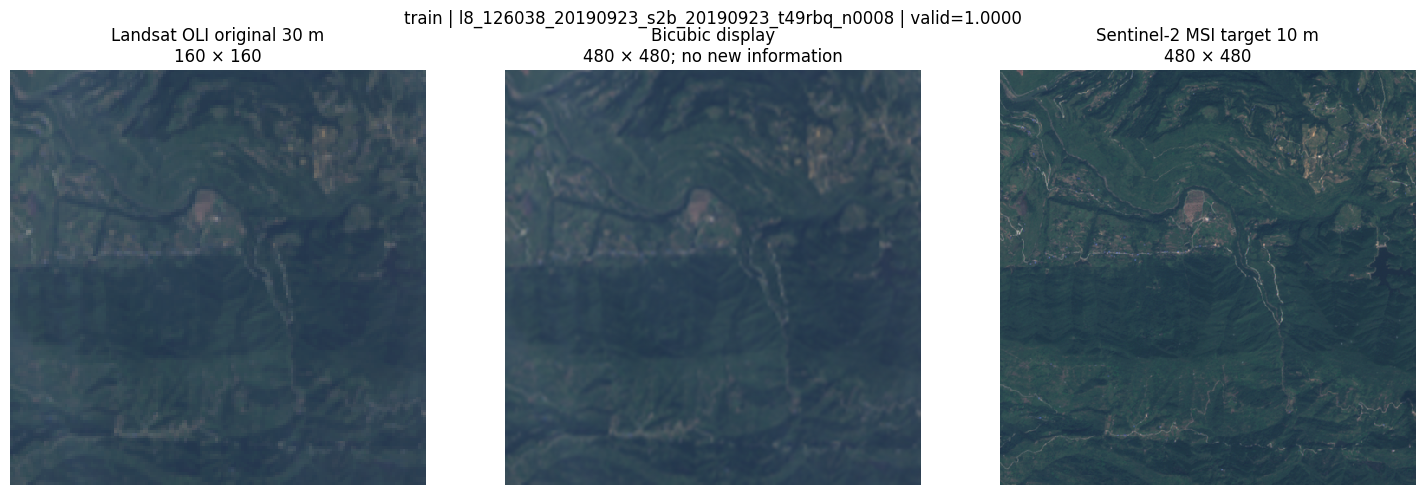

{'lr_shape': (3, 160, 160), 'hr_shape': (3, 480, 480), 'bicubic_l1': 12.935797691345215}


{'hr': tensor([[[0.1921, 0.1882, 0.1882,  ..., 0.1882, 0.1726, 0.1921],
          [0.1843, 0.1882, 0.1921,  ..., 0.1765, 0.1530, 0.2705],
          [0.1960, 0.1960, 0.2000,  ..., 0.1921, 0.1882, 0.2864],
          ...,
          [0.1647, 0.1765, 0.2393,  ..., 0.1530, 0.1608, 0.1569],
          [0.1647, 0.1726, 0.1882,  ..., 0.1412, 0.1490, 0.1569],
          [0.1647, 0.1726, 0.1921,  ..., 0.1451, 0.1412, 0.1412]],
 
         [[0.2981, 0.2981, 0.2942,  ..., 0.2942, 0.2903, 0.2864],
          [0.3020, 0.2981, 0.2981,  ..., 0.2864, 0.2705, 0.3372],
          [0.2981, 0.3059, 0.3137,  ..., 0.3020, 0.2981, 0.3569],
          ...,
          [0.2981, 0.2864, 0.3254,  ..., 0.2432, 0.2666, 0.2705],
          [0.2942, 0.2981, 0.2981,  ..., 0.2432, 0.2471, 0.2588],
          [0.2825, 0.2864, 0.2942,  ..., 0.2549, 0.2393, 0.2354]],
 
         [[0.3254, 0.3176, 0.3215,  ..., 0.3020, 0.3059, 0.3059],
          [0.3254, 0.3215, 0.3215,  ..., 0.2981, 0.2903, 0.3452],
          [0.3254, 0.3254, 0.3254,

In [6]:
from geodiff_gan.data import SentinelPatchDataset
from torch.nn import functional as F

def inspect_pair(index=0, split="train"):
    dataset = SentinelPatchDataset(MANIFEST, split=split, scale=3, augment=False,
        random_degradation=False, input_mode="paired", output_channels=3)
    sample = dataset[int(index) % len(dataset)]
    lr, hr, mask = sample["lr_rgb"], sample["hr"], sample["valid_mask"][0]
    bicubic = F.interpolate(lr[None], size=hr.shape[-2:], mode="bicubic", align_corners=False)[0].clamp(0, 1)
    panels = [(lr, "Landsat OLI original 30 m\n160 × 160"),
              (bicubic, "Bicubic display\n480 × 480; no new information"),
              (hr, "Sentinel-2 MSI target 10 m\n480 × 480")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, (image, title) in zip(axes, panels):
        axis.imshow(image.clamp(0, 1).permute(1, 2, 0), interpolation="nearest")
        axis.set_title(title); axis.axis("off")
    fig.suptitle(f"{split} | {sample['tile_id']} | valid={float(mask.mean()):.4f}")
    fig.tight_layout(); fig.savefig(FIGURE_ROOT / f"pair_{split}_{index}.png", dpi=170); plt.show()
    print({"lr_shape": tuple(lr.shape), "hr_shape": tuple(hr.shape),
           "bicubic_l1": float(((bicubic - hr).abs().mean(0) * mask[0]).sum() / mask[0].sum().clamp_min(1))})
    return sample

inspect_pair(0, "train")


## 6. Audit the OLI2MSI metric protocol

Raw reflectance occupies approximately `0..0.3`. Computing PSNR with data range
one before applying the official stretch inflates PSNR by about 10.46 dB. This
audit reports raw-range, official float and official 8-bit-grid bicubic PSNR.
Only the official protocol is used for model training and evaluation.

In [7]:
def raw_rgb(path, size):
    with rasterio.open(path) as source:
        image = source.read([1, 2, 3], out_dtype="float32") / REFLECTANCE_DIVISOR
        valid = (source.read_masks([1, 2, 3]) > 0).all(0)
    return torch.from_numpy(np.nan_to_num(image)).float(), torch.from_numpy(valid[None]).float()

def protocol_psnr(lr, hr, lr_mask, hr_mask, stretch, quantize):
    if stretch:
        lr = lr.clamp(0, BENCHMARK_REFLECTANCE_MAX) / BENCHMARK_REFLECTANCE_MAX
        hr = hr.clamp(0, BENCHMARK_REFLECTANCE_MAX) / BENCHMARK_REFLECTANCE_MAX
    else:
        lr, hr = lr.clamp(0, 1), hr.clamp(0, 1)
    if quantize:
        lr, hr = lr.mul(255).round().div(255), hr.mul(255).round().div(255)
    prediction = F.interpolate(lr[None], size=hr.shape[-2:], mode="bicubic", align_corners=False)[0].clamp(0, 1)
    mask = hr_mask * F.interpolate(lr_mask[None], size=hr.shape[-2:], mode="nearest")[0]
    expanded = mask.expand_as(hr)
    mse = ((prediction - hr).square() * expanded).sum() / expanded.sum().clamp_min(1)
    return float(-10 * torch.log10(mse.clamp_min(1e-12)))

rows = []
for key, lr_path, hr_path in tqdm(test_pairs[:100], desc="protocol audit", unit="pair"):
    lr, lr_mask = raw_rgb(lr_path, LR_FRAME_SIZE)
    hr, hr_mask = raw_rgb(hr_path, HR_FRAME_SIZE)
    rows.append({"source": key,
        "raw_reflectance_range1": protocol_psnr(lr, hr, lr_mask, hr_mask, False, False),
        "official_clip03_float": protocol_psnr(lr, hr, lr_mask, hr_mask, True, False),
        "official_clip03_uint8_grid": protocol_psnr(lr, hr, lr_mask, hr_mask, True, True)})
protocol_audit = pd.DataFrame(rows)
protocol_audit.to_csv(SUITE_ROOT / "protocol_audit.csv", index=False)
display(protocol_audit.describe().T[["mean", "std", "min", "max"]])
print("Expected range-only inflation:", 20 * np.log10(1 / BENCHMARK_REFLECTANCE_MAX), "dB")


protocol audit:   0%|          | 0/100 [00:00<?, ?pair/s]

,mean,std,min,max
raw_reflectance_range1,42.184408,2.995919,34.459385,49.876423
official_clip03_float,31.763053,2.951468,24.183321,39.418846
official_clip03_uint8_grid,31.745397,2.939267,24.181259,39.333374


Expected range-only inflation: 10.457574905606752 dB


## 7. Validation-only alignment and radiometric ceiling audit

The shift and affine values below are target-assisted diagnostics, not model
outputs. They identify whether registration or radiometry limits achievable
PSNR and must never be reported as inference performance.

In [8]:
from geodiff_gan.data import SentinelPatchDataset

audit_dataset = SentinelPatchDataset(
    MANIFEST, split="val", scale=3, augment=False, random_degradation=False,
    input_mode="paired", output_channels=3,
)

def masked_psnr(prediction, target, mask):
    denominator = (mask.sum() * target.shape[0]).clamp_min(1)
    mse = (((prediction - target) ** 2) * mask).sum() / denominator
    return float(-10 * torch.log10(mse.clamp_min(1e-12)))

def shifted(image, mask, dy, dx):
    value = torch.roll(image, shifts=(dy, dx), dims=(-2, -1))
    valid = mask.clone()
    if dy > 0: valid[..., :dy, :] = 0
    if dy < 0: valid[..., dy:, :] = 0
    if dx > 0: valid[..., :, :dx] = 0
    if dx < 0: valid[..., :, dx:] = 0
    return value, valid

rows = []
limit = len(audit_dataset) if ALIGNMENT_AUDIT_LIMIT is None else min(len(audit_dataset), ALIGNMENT_AUDIT_LIMIT)
for index in range(limit):
    sample = audit_dataset[index]
    lr, hr, mask = sample["lr_rgb"], sample["hr"], sample["valid_mask"][0]
    bicubic = F.interpolate(lr[None], size=hr.shape[-2:], mode="bicubic", align_corners=False)[0].clamp(0, 1)
    original = masked_psnr(bicubic, hr, mask)
    shift_scores = []
    for dy in range(-2, 3):
        for dx in range(-2, 3):
            candidate, overlap = shifted(bicubic, mask, dy, dx)
            shift_scores.append((masked_psnr(candidate, hr, overlap), dy, dx))
    best_shift, dy, dx = max(shift_scores)
    affine = bicubic.clone()
    valid = mask[0] > 0.5
    for channel in range(3):
        x, y = bicubic[channel][valid].double(), hr[channel][valid].double()
        slope = ((x - x.mean()) * (y - y.mean())).mean() / x.var(unbiased=False).clamp_min(1e-12)
        offset = y.mean() - slope * x.mean()
        affine[channel] = (bicubic[channel] * slope.float() + offset.float()).clamp(0, 1)
    affine_score = masked_psnr(affine, hr, mask)
    rows.append({"index": index, "tile": sample["tile_id"], "bicubic_psnr": original,
                 "shift_oracle_psnr": best_shift, "shift_gain": best_shift - original,
                 "best_dy": dy, "best_dx": dx,
                 "affine_oracle_psnr": affine_score, "affine_gain": affine_score - original})

ceiling_audit = pd.DataFrame(rows)
ceiling_audit.to_csv(SUITE_ROOT / "validation_reconstruction_ceiling_audit.csv", index=False)
display(ceiling_audit)
summary = ceiling_audit[["bicubic_psnr", "shift_gain", "affine_gain"]].mean()
display(summary.to_frame("mean"))
if summary["shift_gain"] > 0.2:
    print("WARNING: alignment appears to cap reconstruction. Inspect pair registration before claiming architecture gains.")
if summary["affine_gain"] > 0.2:
    print("WARNING: radiometric mismatch appears important. Test train-only calibration as a separate ablation.")


,index,tile,bicubic_psnr,shift_oracle_psnr,shift_gain,best_dy,best_dx,affine_oracle_psnr,affine_gain
0,0,l8_126038_20190923_s2b_20190923_t49rbq_n0015,33.372616,33.372616,0.0,0,0,34.466743,1.094128
1,1,l8_126038_20190923_s2b_20190923_t49rcq_n0089,31.932827,31.932827,0.0,0,0,32.904362,0.971535
2,2,l8_126038_20190923_s2b_20190923_t49rcq_n0092,31.825296,31.825296,0.0,0,0,32.194489,0.369192
3,3,l8_126038_20190923_s2b_20190923_t49rcq_n0124,32.005749,32.005749,0.0,0,0,32.814583,0.808834
4,4,l8_126038_20190923_s2b_20190923_t49rcq_n0162,31.423325,31.423325,0.0,0,0,31.765343,0.342018
...,...,...,...,...,...,...,...,...,...
95,95,l8_126040_20190923_s2b_20190923_t49rbm_n0217,30.414883,30.414883,0.0,0,0,30.725876,0.310993
96,96,l8_126040_20190923_s2b_20190923_t49rbm_n0254,29.970114,29.970114,0.0,0,0,30.307444,0.337330
97,97,l8_126040_20190923_s2b_20190923_t49rbm_n0256,30.601860,30.601860,0.0,0,0,31.188263,0.586403
98,98,l8_126040_20190923_s2b_20190923_t49rbm_n0259,32.662399,32.662399,0.0,0,0,33.335346,0.672947


,mean
bicubic_psnr,32.314740
shift_gain,0.006044
affine_gain,1.019290


## 8. Run registry and bounded training helpers

In [9]:
import copy, yaml
RESULTS = {}

def save_state():
    value = {"manifest": str(MANIFEST), "manifest_sha256": sha256(MANIFEST),
             "results": RESULTS, "repository": str(REPOSITORY_DIR),
             "source_sha256": source_digest}
    temporary = SUITE_ROOT / "suite_state.json.tmp"
    temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
    temporary.replace(SUITE_ROOT / "suite_state.json")

if (SUITE_ROOT / "suite_state.json").exists():
    state = json.loads((SUITE_ROOT / "suite_state.json").read_text())
    if state["manifest_sha256"] != sha256(MANIFEST):
        raise ValueError("Saved registry uses a different manifest")
    RESULTS.update(state["results"])
save_state()

def calibration_for(profile):
    if profile not in ("rgb_harmonized_fidelity", "multispectral_guided_fidelity"):
        return None
    key = "lr_ms" if profile.startswith("multispectral") else "lr"
    path = SUITE_ROOT / "calibration" / f"{key}_train_only.json"
    lock_json(path.with_suffix(".lock.json"), {"manifest_sha256": sha256(MANIFEST), "key": key})
    if not path.exists():
        run([sys.executable, "-m", "geodiff_gan.cli.fit_radiometric",
             "--manifest", MANIFEST, "--output", path, "--condition-key", key,
             "--scale", 3, "--maximum-patches", 50 if FAST_DEV_RUN else 1000,
             "--seed", RANDOM_SEED], REPOSITORY_DIR)
    return path

def make_config(profile, root, crop_size=None):
    crop_size = TRAIN_LR_CROP if crop_size is None else int(crop_size)
    config = experiment_config(
        REPOSITORY_DIR, profile, MANIFEST, root, experts=NUM_EXPERTS,
        top_k=TOP_K, crop_size=crop_size, calibration=calibration_for(profile),
        multispectral=NEW_MULTISPECTRAL, fast=FAST_DEV_RUN,
    )
    if profile in NEW_PROFILES:
        config["model"].update(
            base_architecture="residual_swin", base_embed_dim=48,
            base_groups=4, base_depth=3, base_heads=4, window_size=8,
            base_upsample_mode="resize_conv",
        )
        config["training"].update(
            batch_size=2, gradient_accumulation=8, weight_decay=0.0,
            validation_limit=RESIDUAL_VALIDATION_LIMIT,
            early_stopping_patience=6, early_stopping_min_epochs=8,
        )
        config["experiment"].update(
            strong_base="residual_swin_48_g4_d3",
            progressive_crops=[32, 64, 128],
            psnr_first_base=True, dataset_protocol=DATA_PROTOCOL_ID, full_frame_geometry=[LR_FRAME_SIZE, HR_FRAME_SIZE],
        )
    configured = config["training"].get("validation_limit")
    validation_count = sum(record.split == "val" for record in records)
    if configured is not None:
        config["training"]["validation_limit"] = min(int(configured), validation_count)
    return config

def configure_psnr_base(config):
    config = copy.deepcopy(config)
    config["training"]["loss_weights"].update(
        mse=100.0, multiscale_mse=10.0, charbonnier=0.1, ssim=0.1,
        consistency=0.0, gradient=0.0, wavelet=0.0, perceptual=0.0,
        adversarial=0.0, radiometric=0.0, residual_supervision=0.0,
        base_guard=0.0,
    )
    return config

def register(name, root, config, checkpoint):
    RESULTS[name] = {"root": str(root), "config": str(config),
                     "checkpoint": str(checkpoint),
                     "checkpoint_sha256": sha256(checkpoint)}
    save_state()

def run_earlier(profile):
    if not RUN_EARLIER[profile]:
        print("Skipped extra-session profile:", profile)
        return
    if profile.startswith("multispectral") and not INCLUDE_MULTISPECTRAL:
        raise ValueError("Enable multispectral preparation first")
    root = EXPERIMENT_ROOT / (profile + "_resize_control")
    config = make_config(profile, root)
    parent = None
    for stage in ("base", "vae", "diffusion", "joint"):
        minutes = {**SHARED_MINUTES, **PER_EXPERIMENT_MINUTES}[stage]
        config_path, parent = run_stage(
            REPOSITORY_DIR, config, root, stage, parent=parent,
            epochs=EPOCHS[stage], minutes=minutes, fast=FAST_DEV_RUN,
        )
    register(profile + "_resize_control", root, config_path, parent)

prefix = "ms" if NEW_MULTISPECTRAL else "rgb"
BASE_ROOT = EXPERIMENT_ROOT / f"{prefix}_strong_base_full128"
BASE_CONFIG = make_config("residual_base", BASE_ROOT, crop_size=128)
report = []
for profile in NEW_PROFILES:
    config = make_config(profile, EXPERIMENT_ROOT / f"{prefix}_{profile}")
    model = GeoDiffGAN.from_config(config)
    assert not any(isinstance(module, torch.nn.PixelShuffle) for module in model.modules())
    report.append({"profile": profile,
                   "parameters": sum(p.numel() for p in model.parameters()),
                   "base_parameters": sum(p.numel() for p in model.base.parameters()),
                   "experts": config["model"]["diffusion_experts"],
                   "top_k": config["model"]["diffusion_top_k"]})
    del model
display(pd.DataFrame(report))


,profile,parameters,base_parameters,experts,top_k
0,residual_base,4046618,365667,0,1
1,single_expert,4050296,365667,1,1
2,generic_moe,4055426,365667,4,1
3,reliability_moe,4055426,365667,4,1


## 9. Train the progressive strong base

Each phase starts from the previous phase's best checkpoint but writes to a new
immutable directory. Validation always uses complete stored patches. Intermediate
base checkpoints are registered for an honest validation comparison.

In [10]:
phase_parent = None
best_phase = None
phase_outputs = []
for phase_index, phase in enumerate(BASE_PHASES):
    phase_root = EXPERIMENT_ROOT / f"{prefix}_strong_base_{phase['name']}"
    phase_config = configure_psnr_base(
        make_config("residual_base", phase_root, crop_size=phase["crop"])
    )
    phase_config["training"]["validation_limit"] = BASE_VALIDATION_LIMIT
    config_path, checkpoint = run_stage(
        REPOSITORY_DIR, phase_config, phase_root, "base", parent=phase_parent,
        epochs=phase["epochs"], minutes=phase["minutes"], fast=FAST_DEV_RUN,
        learning_rate=phase["learning_rate"],
        max_batches_per_epoch=phase["max_batches"],
    )
    payload = torch.load(checkpoint, map_location="cpu", weights_only=False)
    metrics = payload.get("extra", {}).get("metrics", {})
    if "val_psnr" not in metrics:
        raise RuntimeError(f"Base checkpoint lacks val_psnr: {checkpoint}")
    val_psnr = float(metrics["val_psnr"])
    name = f"{prefix}_{phase['name']}_residual_base"
    register(name, phase_root, config_path, checkpoint)
    row = {"phase": phase["name"], "crop": phase["crop"],
           "validation_psnr": val_psnr, "checkpoint": str(checkpoint),
           "sha256": sha256(checkpoint), "result_name": name}
    phase_outputs.append(row)
    if best_phase is None or val_psnr > best_phase["validation_psnr"]:
        best_phase = row
        phase_parent = checkpoint
        print("New best base phase:", phase["name"], val_psnr)
    else:
        print("Phase did not beat its parent; retaining", best_phase["phase"],
              best_phase["validation_psnr"], "instead of", phase["name"], val_psnr)
    del payload

selected = RESULTS.pop(best_phase["result_name"])
BASE_ROOT = Path(selected["root"])
BASE_CONFIG_PATH = Path(selected["config"])
BASE_CHECKPOINT = Path(selected["checkpoint"])
register(f"{prefix}_residual_base", BASE_ROOT, BASE_CONFIG_PATH, BASE_CHECKPOINT)
(SUITE_ROOT / "strong_base_phases.json").write_text(json.dumps(phase_outputs, indent=2))
display(pd.DataFrame(phase_outputs))
print("Validation-selected shared strong base:", best_phase["phase"], BASE_CHECKPOINT)


New best base phase: crop32 33.977239322662356
New best base phase: crop64 34.02190265655518
New best base phase: crop128 34.02375909805298


,phase,crop,validation_psnr,checkpoint,sha256,result_name
0,crop32,32,33.977239,/kaggle/working/geodiff-oli2msi-strong-v1/expe...,fdc90936b0d780c26c9ae807dedd42d94067274baddbcc...,rgb_crop32_residual_base
1,crop64,64,34.021903,/kaggle/working/geodiff-oli2msi-strong-v1/expe...,f8cc1a404d7de02963171ed44d412b0d4f2b6a231caa0e...,rgb_crop64_residual_base
2,crop128,128,34.023759,/kaggle/working/geodiff-oli2msi-strong-v1/expe...,990637466e10c958fa80c02a25621a048b6cf65ca4f5bb...,rgb_crop128_residual_base


Validation-selected shared strong base: crop128 /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop128/runs/base/base_best.pt


## 10. Freeze the strong base and train the shared residual representation

In [11]:
VAE_ROOT = EXPERIMENT_ROOT / f"{prefix}_shared_vae"
VAE_CONFIG = make_config("residual_base", VAE_ROOT, crop_size=TRAIN_LR_CROP)
VAE_CONFIG_PATH, VAE_CHECKPOINT = run_stage(REPOSITORY_DIR, VAE_CONFIG, VAE_ROOT, "vae",
    parent=BASE_CHECKPOINT, epochs=EPOCHS["vae"], minutes=SHARED_MINUTES["vae"], fast=FAST_DEV_RUN)
print("Shared VAE lineage:", VAE_CHECKPOINT)

def run_new(profile):
    root = EXPERIMENT_ROOT / f"{prefix}_{profile}"
    config = make_config(profile, root)
    parent = VAE_CHECKPOINT
    for stage in ("diffusion", "joint"):
        config_path, parent = run_stage(REPOSITORY_DIR, config, root, stage, parent=parent,
            epochs=EPOCHS[stage], minutes=PER_EXPERIMENT_MINUTES[stage], fast=FAST_DEV_RUN)
    register(f"{prefix}_{profile}", root, config_path, parent)
    return RESULTS[f"{prefix}_{profile}"]


Shared VAE lineage: /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_shared_vae/runs/vae/vae_best.pt


## 11A. One-expert residual control

In [12]:
display(run_new("single_expert"))


diffusion train 1/12: 100%|██████████| 120/120 [00:13<00:00, 11.13batch/s, avg=0.2765, loss=0.4163, lr=1.00e-04]
                                                                                                                
diffusion train 2/12:  99%|█████████▉| 119/120 [00:10<00:00, 11.10batch/s, avg=0.2510, loss=0.0339, lr=1.00e-04]
                                                                                                                
diffusion train 3/12: 100%|██████████| 120/120 [00:11<00:00, 10.81batch/s, avg=0.2327, loss=0.3569, lr=1.00e-04]
                                                                                                                
diffusion train 4/12: 100%|██████████| 120/120 [00:11<00:00, 10.69batch/s, avg=0.2056, loss=0.0244, lr=1.00e-04]
                                                                                                                
diffusion train 5/12: 100%|██████████| 120/120 [00:11<00:00, 10.69batch/s, avg=0.1908, loss=0.23

[joint] early stopping after epoch 8: val_psnr did not improve by 0.0001 for 7 validation checks


joint epochs:  88%|████████▊ | 7/8 [06:17<00:53, 53.86s/epoch, train_loss=0.1737, val_psnr=35.15]


{'root': '/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_single_expert',
 'config': '/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_single_expert/configs/joint.yaml',
 'checkpoint': '/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_single_expert/runs/joint/joint_best.pt',
 'checkpoint_sha256': '62ab8d29715097fadbe2306929db0fcd3505ede1b58466eb5132c2c2bdab0233'}

## 11B. Generic routed experts

In [ ]:
display(run_new("generic_moe"))


diffusion train 1/12:  99%|█████████▉| 119/120 [00:13<00:00, 10.54batch/s, avg=0.2764, loss=0.4164, lr=1.00e-04]
                                                                                                                
diffusion train 2/12: 100%|██████████| 120/120 [00:12<00:00, 10.05batch/s, avg=0.2513, loss=0.0341, lr=1.00e-04]
                                                                                                                
diffusion train 3/12: 100%|██████████| 120/120 [00:11<00:00, 10.94batch/s, avg=0.2328, loss=0.3574, lr=1.00e-04]
                                                                                                                
diffusion train 4/12: 100%|██████████| 120/120 [00:11<00:00, 10.78batch/s, avg=0.2054, loss=0.0245, lr=1.00e-04]
                                                                                                                
diffusion train 5/12:  99%|█████████▉| 119/120 [00:11<00:00, 10.60batch/s, avg=0.1908, loss=0.23

## 11C. Reliability-supervised experts

In [16]:
display(run_new("reliability_moe"))


{'root': '/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_reliability_moe',
 'config': '/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_reliability_moe/configs/joint.yaml',
 'checkpoint': '/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_reliability_moe/runs/joint/joint_best.pt',
 'checkpoint_sha256': '7338147a92f8334715a0dc6c98cd77a84703b9d1112f6a4729c2e05a0de5e252'}

## 12. Validate all available models, with the same full frames and sampling seeds
Model selection uses validation, not test. Final residual scale is **1.0**; the base-only
control uses scale 0. A model that cannot beat its own base is a failed refinement,
even when it beats bicubic. VAE teacher-forced metrics are not inference metrics.
Raw reflectance range 0..1 is kept throughout; do not compare these numbers directly
with other papers using clip03, uint8, different crops, or different scene pairs.
For the time-limited screening run, validation uses a fixed source-ID subset.
Use `EVAL_LIMIT=None` in a new evaluation directory for a complete validation report.

In [17]:
def evaluate_result(name, split="val"):
    item = RESULTS[name]
    root = Path(item["root"]) / "evaluation" / split
    base_only = name.endswith("residual_base")
    limit = TEST_EVAL_LIMIT if split == "test" else EVAL_LIMIT
    settings = {"checkpoint_sha256": sha256(item["checkpoint"]), "config_sha256": sha256(item["config"]),
                "manifest_sha256": sha256(MANIFEST), "split": split, "limit": limit,
                "samples": 1 if base_only else EVAL_SAMPLES, "steps": 1 if base_only else EVAL_STEPS,
                "residual_scale": 0.0 if base_only else 1.0}
    lock_json(root / "evaluation_lock.json", settings)
    metric_path = root / "model/metrics.json"
    if not metric_path.exists():
        command = [sys.executable, "-m", "geodiff_gan.cli.evaluate", "--config", item["config"],
            "--checkpoint", item["checkpoint"], "--output", root / "model", "--split", split,
            "--samples", settings["samples"], "--steps", settings["steps"],
            "--residual-scale", settings["residual_scale"], "--back-projection-steps", 0,
            "--no-text", "--device", "cuda", "--progress", "compact"]
        if limit is not None: command += ["--limit", limit]
        run(command, REPOSITORY_DIR)
    baseline_path = root / "baselines.json"
    if not baseline_path.exists():
        command = [sys.executable, "-m", "geodiff_gan.cli.baselines", "--config", item["config"],
            "--base-checkpoint", item["checkpoint"], "--output", baseline_path, "--split", split,
            "--device", "cuda", "--progress", "quiet"]
        if limit is not None: command += ["--limit", limit]
        run(command, REPOSITORY_DIR)
    return {"experiment": name, **json.loads(metric_path.read_text())}

def append_bicubic(table, split):
    canonical = RESULTS[f"{prefix}_residual_base"]
    path = Path(canonical["root"]) / "evaluation" / split / "baselines.json"
    payload = json.loads(path.read_text())
    row = {"experiment": "bicubic", "count": payload.get("count"), **payload["bicubic"]}
    return pd.concat([pd.DataFrame([row]), table], ignore_index=True, sort=False)

validation_table = append_bicubic(
    pd.DataFrame([evaluate_result(name, "val") for name in RESULTS]), "val"
)
validation_table.to_csv(SUITE_ROOT / "validation_summary.csv", index=False)
display(validation_table[["experiment", "count", "psnr", "base_psnr", "psnr_delta_vs_base", "ssim",
                          "l1", "edge_f1", "ergas", "sam_degrees", "uiqi", "scc", "fraction_beating_base_psnr"]])


+ /usr/bin/python3 -m geodiff_gan.cli.evaluate --config /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/configs/base.yaml --checkpoint /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/runs/base/base_best.pt --output /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/evaluation/val/model --split val --samples 1 --steps 1 --residual-scale 0.0 --back-projection-steps 0 --no-text --device cuda --progress compact --limit 100
[evaluate] device=cuda (Tesla T4) torch=2.10.0+cu128 cuda=12.8
[evaluate] amp=True
[evaluate] building GeoDiff-GAN
[evaluate] loading checkpoint /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/runs/base/base_best.pt
[evaluate] text conditioning disabled; using zero context
[evaluate] remote-sensing metrics enabled: ERGAS, SAM, UIQI, sCC
[evaluate] loading val dataset
[evaluate] plan patches=100 samples=1 steps=1 diffusion_unet_passes=100
[evaluate] patch 1/100

,experiment,count,psnr,base_psnr,psnr_delta_vs_base,ssim,l1,edge_f1,ergas,sam_degrees,uiqi,scc,fraction_beating_base_psnr
0,bicubic,100,32.314738,NaN,NaN,0.887500,0.015329,0.231902,3.851966,2.416947,0.869630,0.220745,NaN
1,rgb_crop32_residual_base,100,33.977239,33.977239,0.000000,0.912692,0.012033,0.647267,3.290506,1.295940,0.900416,0.309289,0.00
2,rgb_crop64_residual_base,100,34.021903,34.021903,0.000000,0.912959,0.011993,0.644154,3.272654,1.282129,0.900476,0.315204,0.00
3,rgb_residual_base,100,34.023759,34.023759,0.000000,0.912954,0.011989,0.642497,3.272107,1.280486,0.900588,0.315197,0.00
4,rgb_single_expert,100,34.013761,34.023759,-0.009998,0.913251,0.012004,0.647896,3.275783,1.281551,0.900999,0.314487,0.10
5,rgb_generic_moe,100,34.013935,34.023759,-0.009824,0.913244,0.012004,0.647885,3.275745,1.281640,0.900983,0.314457,0.11
6,rgb_reliability_moe,100,34.015711,34.023759,-0.008048,0.913227,0.012000,0.647262,3.275132,1.281190,0.900954,0.314673,0.13


## 13. Save comparison plots and paired validation confidence intervals

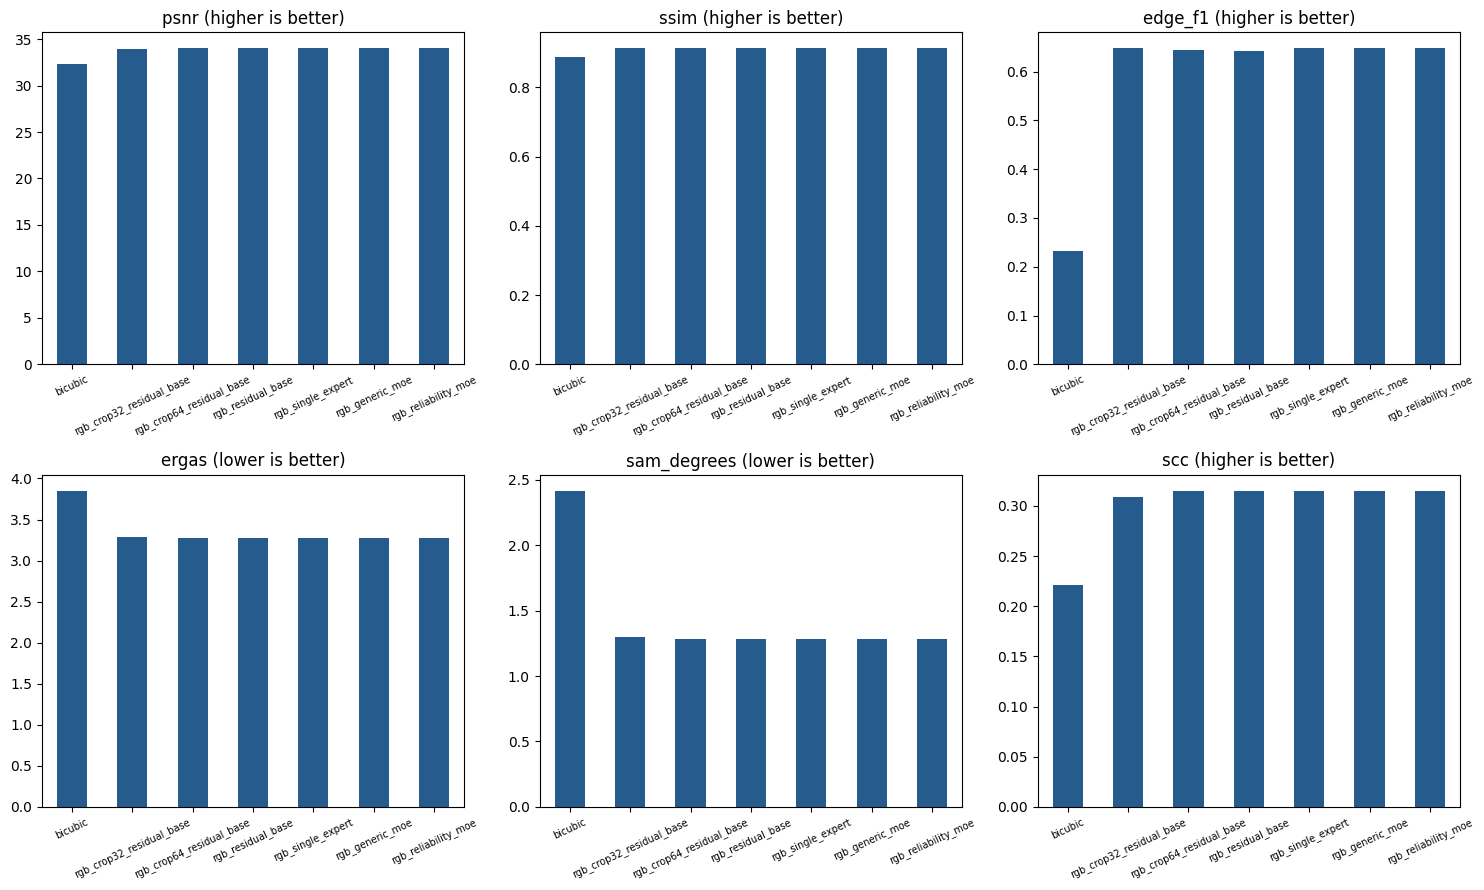

,experiment,mean_delta,ci_low,ci_high,fraction_beating_base
0,rgb_crop32_residual_base,0.000000,0.000000,0.000000,0.00
1,rgb_crop64_residual_base,0.000000,0.000000,0.000000,0.00
2,rgb_residual_base,0.000000,0.000000,0.000000,0.00
3,rgb_single_expert,-0.009998,-0.011559,-0.008332,0.10
4,rgb_generic_moe,-0.009824,-0.011334,-0.008221,0.11
5,rgb_reliability_moe,-0.008048,-0.009382,-0.006651,0.13


Pair bootstrap is descriptive. Report the fixed official test set and add scene/source-grouped uncertainty when source dependencies are known.


In [18]:
def plot_summary(table, split):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for axis, metric in zip(axes.flat, ("psnr", "ssim", "edge_f1", "ergas", "sam_degrees", "scc")):
        table.plot.bar(x="experiment", y=metric, ax=axis, legend=False, color="#265b8e")
        axis.set_title(metric + (" (lower is better)" if metric in ("ergas", "sam_degrees") else " (higher is better)"))
        axis.set_xlabel("")
        axis.tick_params(axis="x", labelsize=7, rotation=25)
    fig.tight_layout()
    fig.savefig(FIGURE_ROOT / f"{split}_metrics.png", dpi=170)
    plt.show()

plot_summary(validation_table, "val")
bootstrap_rows = []
for name, item in RESULTS.items():
    rows = [json.loads(line) for line in (Path(item["root"]) / "evaluation/val/model/per_patch_metrics.jsonl").read_text().splitlines()]
    deltas = np.array([r["psnr_delta_vs_base"] for r in rows])
    rng = np.random.default_rng(RANDOM_SEED)
    bootstrap = np.array([rng.choice(deltas, size=len(deltas), replace=True).mean() for _ in range(2000)])
    bootstrap_rows.append({"experiment": name, "mean_delta": deltas.mean(),
        "ci_low": np.quantile(bootstrap, .025), "ci_high": np.quantile(bootstrap, .975),
        "fraction_beating_base": float((deltas > 0).mean())})
bootstrap_table = pd.DataFrame(bootstrap_rows)
bootstrap_table.to_csv(SUITE_ROOT / "validation_bootstrap.csv", index=False)
display(bootstrap_table)
print("Pair bootstrap is descriptive. Report the fixed official test set and add scene/source-grouped uncertainty when source dependencies are known.")


## 14. Routing diagnostics: utilization, acceptance and actual training time

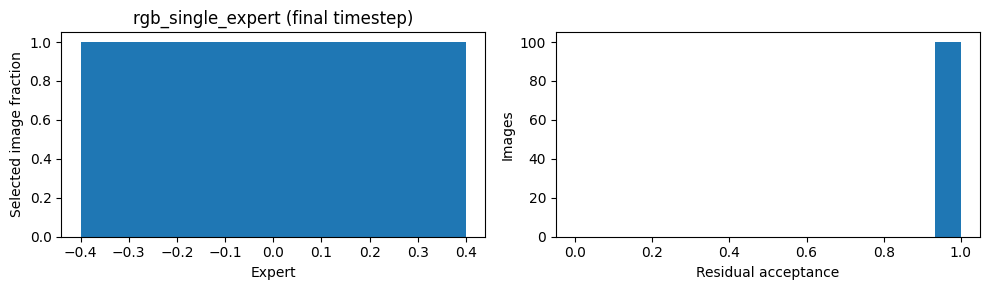

Dead experts: []


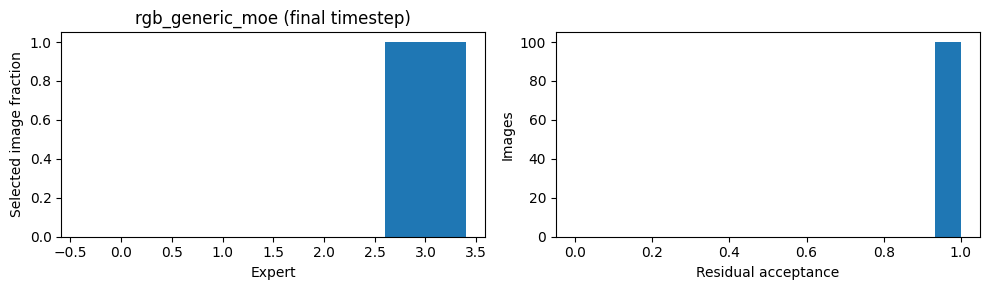

Dead experts: [0, 1, 2]


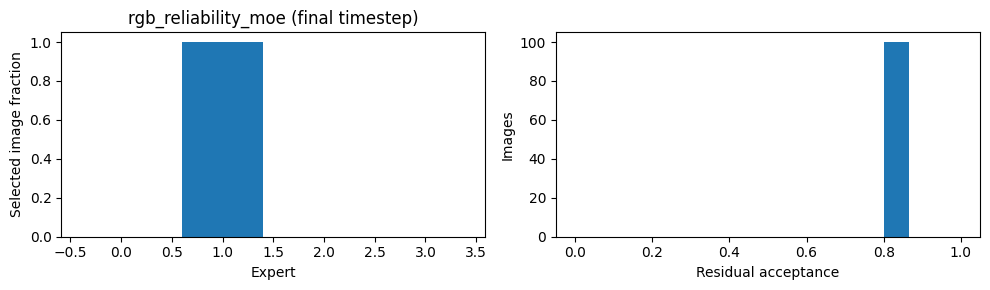

Dead experts: [0, 2, 3]


,experiment,stage,best_epoch,completed_epochs,batches,optimizer_step_attempts,stage_minutes
0,rgb_crop32_residual_base,base,28,30,12000,1500,18.834583
1,rgb_crop64_residual_base,base,23,24,4320,552,8.666372
2,rgb_residual_base,base,2,8,480,64,2.466251
3,rgb_single_expert,diffusion,12,12,1440,180,2.877150
4,rgb_single_expert,joint,3,8,960,120,6.268193
5,rgb_generic_moe,diffusion,12,12,1440,180,2.972292
6,rgb_generic_moe,joint,1,8,960,120,6.266084
7,rgb_reliability_moe,diffusion,12,12,1440,180,4.610063
8,rgb_reliability_moe,joint,1,8,960,120,6.419610


Training loss/usage histories: [PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop128/runs/base/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_single_expert/runs/diffusion/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_single_expert/runs/joint/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/runs/base/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_shared_vae/runs/vae/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_reliability_moe/runs/diffusion/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_reliability_moe/runs/joint/training_history.jsonl'), PosixPath('/kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop64/runs/base/training_histo

In [19]:
history_rows = []
from geodiff_gan.training.checkpoint import latest_stage_checkpoint
for name, item in RESULTS.items():
    root = Path(item["root"])
    path = root / "evaluation/val/model/per_patch_metrics.jsonl"
    rows = [json.loads(line) for line in path.read_text().splitlines()]
    routed = [row for row in rows if row.get("expert_weights")]
    if routed:
        weights = np.asarray([row["expert_weights"] for row in routed])
        acceptance = np.asarray([row["router_acceptance"] for row in routed])
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        axes[0].bar(np.arange(weights.shape[1]), (weights > 0).mean(0))
        axes[0].set(xlabel="Expert", ylabel="Selected image fraction", title=name + " (final timestep)")
        axes[1].hist(acceptance, bins=15, range=(0, 1))
        axes[1].set(xlabel="Residual acceptance", ylabel="Images")
        fig.tight_layout(); fig.savefig(FIGURE_ROOT / f"{name}_routing.png", dpi=150); plt.show()
        print("Dead experts:", np.where((weights > 0).sum(0) == 0)[0].tolist())
    for done in root.glob("runs/*/completed.json"):
        stage = done.parent.name
        # Compact checkpoint headers still require trusted local torch files.
        saved = json.loads(done.read_text())
        payload = torch.load(saved["checkpoint"], map_location="cpu", weights_only=False)
        last = torch.load(latest_stage_checkpoint(done.parent, stage), map_location="cpu", weights_only=False)
        history_rows.append({"experiment": name, "stage": stage, "best_epoch": payload["epoch"] + 1,
                             "completed_epochs": last["epoch"] + 1,
                             "batches": last["extra"].get("total_train_batches"),
                             "optimizer_step_attempts": last["extra"].get("total_optimizer_step_attempts"),
                             "stage_minutes": last["extra"].get("stage_elapsed_seconds", 0) / 60,
                             "best_metrics": payload["extra"]["metrics"]})
        del payload, last
(SUITE_ROOT / "training_selection.json").write_text(json.dumps(history_rows, indent=2))
display(pd.DataFrame(history_rows).drop(columns=["best_metrics"], errors="ignore"))
print("Training loss/usage histories:", list(EXPERIMENT_ROOT.glob("*/runs/*/training_history.jsonl")))


## 15. Locked test evaluation (enable after reviewing validation)
No settings are selected on these results. Every available model uses the same test
manifest, full 160→480 frames, sample count and seeds. A smoke-run limit is not a
publishable evaluation. Leave the test set closed while debugging or changing the design.

+ /usr/bin/python3 -m geodiff_gan.cli.evaluate --config /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/configs/base.yaml --checkpoint /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/runs/base/base_best.pt --output /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/evaluation/test/model --split test --samples 1 --steps 1 --residual-scale 0.0 --back-projection-steps 0 --no-text --device cuda --progress compact --limit 100
[evaluate] device=cuda (Tesla T4) torch=2.10.0+cu128 cuda=12.8
[evaluate] amp=True
[evaluate] building GeoDiff-GAN
[evaluate] loading checkpoint /kaggle/working/geodiff-oli2msi-strong-v1/experiments/rgb_strong_base_crop32/runs/base/base_best.pt
[evaluate] text conditioning disabled; using zero context
[evaluate] remote-sensing metrics enabled: ERGAS, SAM, UIQI, sCC
[evaluate] loading test dataset
[evaluate] plan patches=100 samples=1 steps=1 diffusion_unet_passes=100
[evaluate] patch 1/

,experiment,count,psnr,base_psnr,psnr_delta_vs_base,ssim,l1,edge_f1,ergas,sam_degrees,uiqi,scc
0,bicubic,100,31.745724,NaN,NaN,0.878459,0.016503,0.214750,3.907100,2.394568,0.870735,0.220296
1,rgb_crop32_residual_base,100,33.423247,33.423247,0.000000,0.906136,0.012961,0.620142,3.338628,1.297331,0.901246,0.306987
2,rgb_crop64_residual_base,100,33.478727,33.478727,0.000000,0.906484,0.012850,0.619313,3.318009,1.286683,0.901374,0.312990
3,rgb_residual_base,100,33.479478,33.479478,0.000000,0.906464,0.012852,0.617680,3.317718,1.286116,0.901516,0.312903
4,rgb_single_expert,100,33.473015,33.479478,-0.006463,0.906830,0.012869,0.622859,3.319846,1.287261,0.901919,0.312317
5,rgb_generic_moe,100,33.473119,33.479478,-0.006359,0.906823,0.012869,0.622903,3.319813,1.287294,0.901905,0.312285
6,rgb_reliability_moe,100,33.474416,33.479478,-0.005062,0.906798,0.012865,0.622330,3.319417,1.286896,0.901875,0.312484


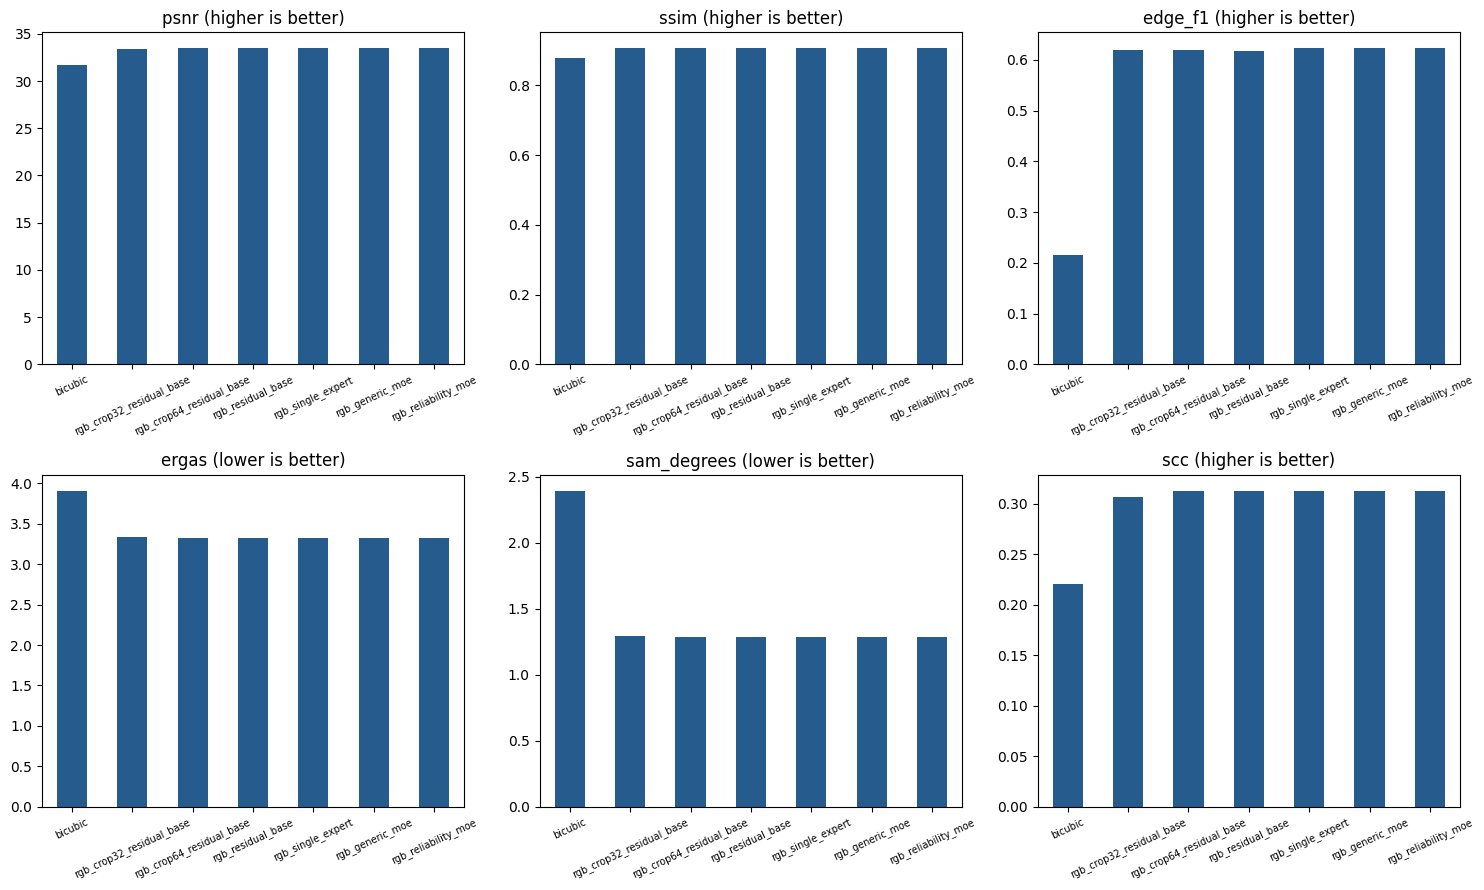

In [20]:
# Set True here once validation choices are final, then run this cell.
if RUN_TEST_EVALUATION:
    test_table = append_bicubic(
        pd.DataFrame([evaluate_result(name, "test") for name in RESULTS]), "test"
    )
    test_table.to_csv(SUITE_ROOT / "test_summary.csv", index=False)
    display(test_table[["experiment", "count", "psnr", "base_psnr", "psnr_delta_vs_base", "ssim",
                        "l1", "edge_f1", "ergas", "sam_degrees", "uiqi", "scc"]])
    plot_summary(test_table, "test")
else:
    print("Test remains locked. Set RUN_TEST_EVALUATION=True after validation review.")


## 16. Indexed comparison: original LR, each model and HR (at most three panels per row)

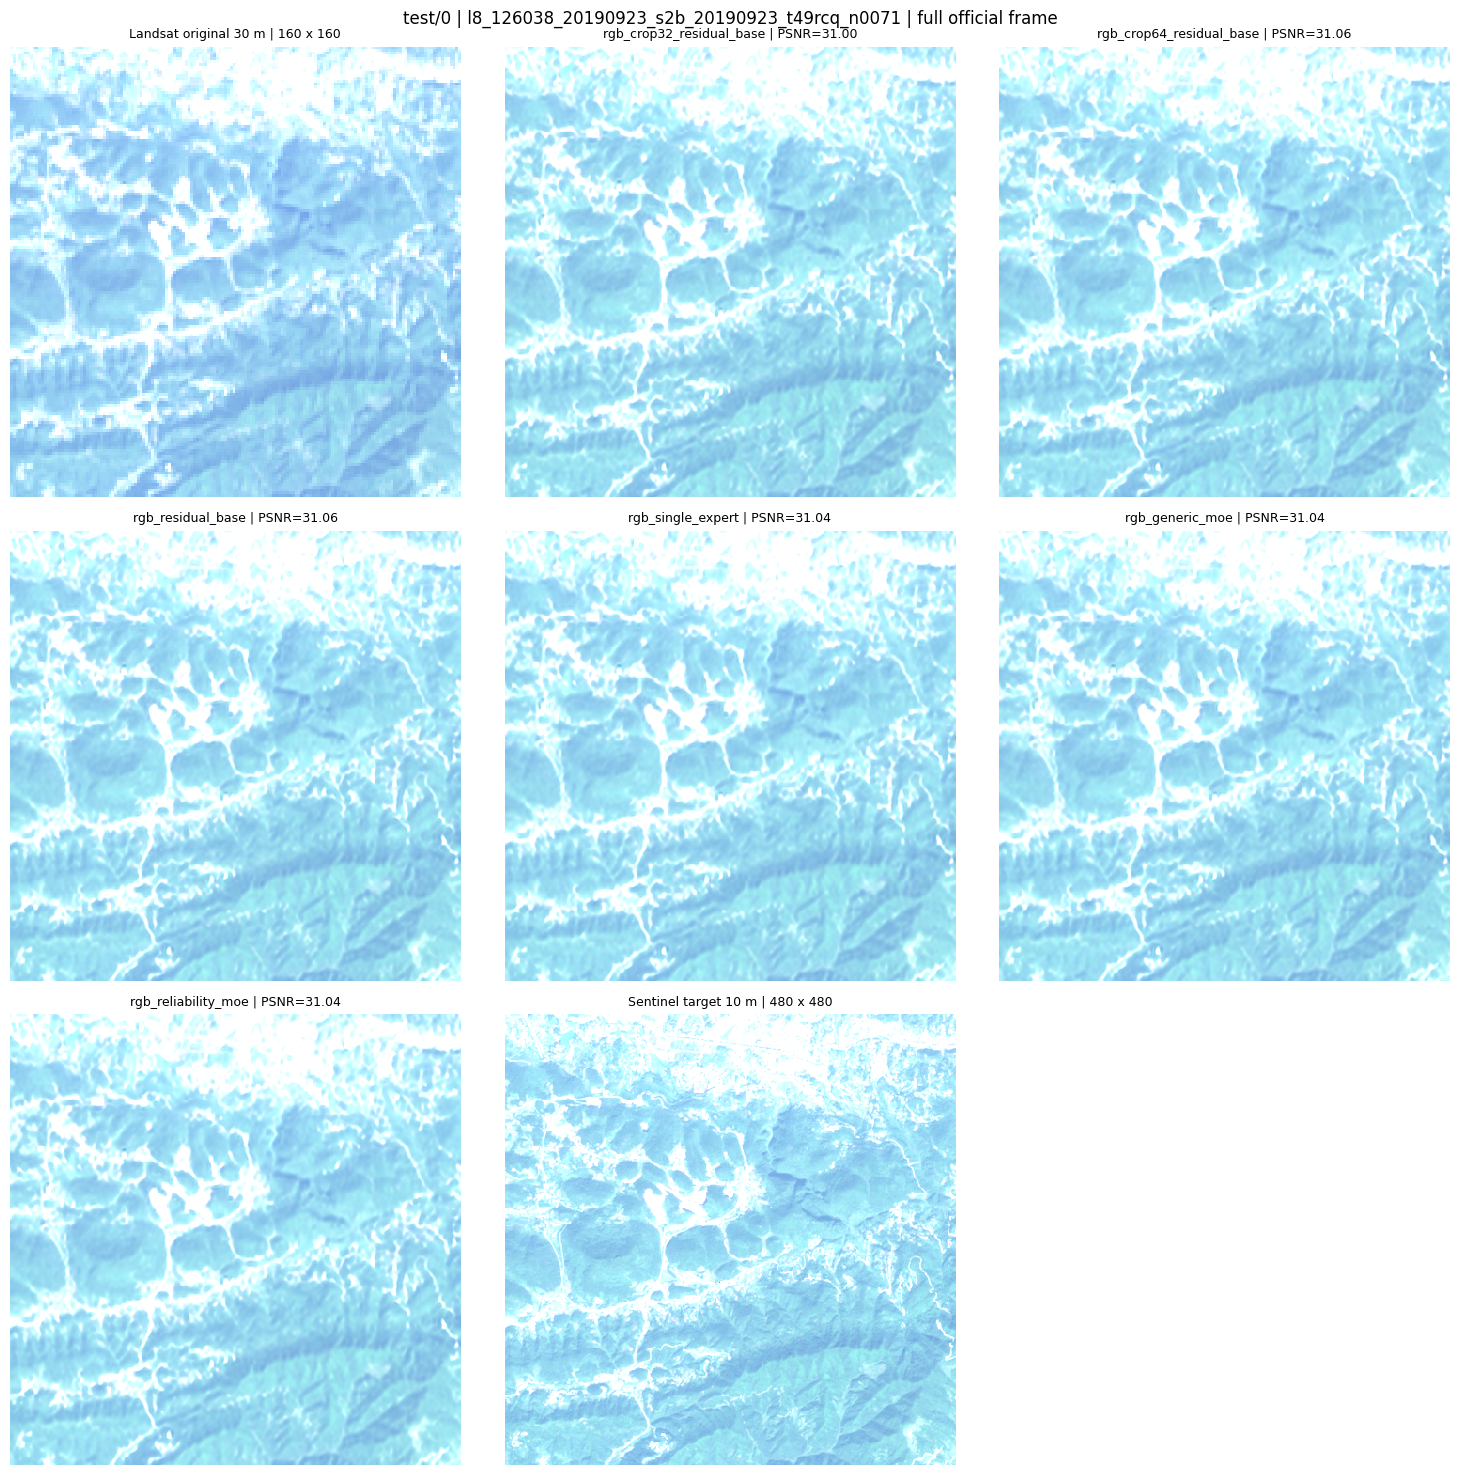

Saved: /kaggle/working/geodiff-oli2msi-strong-v1/figures/compare_test_0_1788333993.png


{'record': {'caption': '',
  'col': 0,
  'day_gap': 0,
  'landsat_acquisition': '',
  'landsat_product': 'L8_126038_20190923_S2B_20190923_T49RCQ_N0071.TIF',
  'license_id': 'see-official-OLI2MSI-distribution',
  'patch': '/kaggle/working/geodiff-oli2msi-strong-v1/dataset/patches/test/l8_126038_20190923_s2b_20190923_t49rcq_n0071.npz',
  'row': 0,
  'scale': 3,
  'sentinel_acquisition': '',
  'sentinel_product': 'L8_126038_20190923_S2B_20190923_T49RCQ_N0071.TIF',
  'source': 'oli2msi_official_full160_clip03_uint8grid_v1',
  'source_product': 'test:l8_126038_20190923_s2b_20190923_t49rcq_n0071',
  'split': 'test',
  'target_crs': '',
  'target_transform': None,
  'tile_id': 'l8_126038_20190923_s2b_20190923_t49rcq_n0071',
  'valid_fraction': 1.0},
 'display': 'Fixed common reflectance stretch; metrics use unchanged arrays',
 'models': {'rgb_crop32_residual_base': {'psnr': np.float64(30.996621263628377),
   'l1': 0.014632088132202625,
   'expert_weights': [],
   'router_acceptance': 1.0},
  

{'record': {'caption': '',
  'col': 0,
  'day_gap': 0,
  'landsat_acquisition': '',
  'landsat_product': 'L8_126038_20190923_S2B_20190923_T49RCQ_N0071.TIF',
  'license_id': 'see-official-OLI2MSI-distribution',
  'patch': '/kaggle/working/geodiff-oli2msi-strong-v1/dataset/patches/test/l8_126038_20190923_s2b_20190923_t49rcq_n0071.npz',
  'row': 0,
  'scale': 3,
  'sentinel_acquisition': '',
  'sentinel_product': 'L8_126038_20190923_S2B_20190923_T49RCQ_N0071.TIF',
  'source': 'oli2msi_official_full160_clip03_uint8grid_v1',
  'source_product': 'test:l8_126038_20190923_s2b_20190923_t49rcq_n0071',
  'split': 'test',
  'target_crs': '',
  'target_transform': None,
  'tile_id': 'l8_126038_20190923_s2b_20190923_t49rcq_n0071',
  'valid_fraction': 1.0},
 'display': 'Fixed common reflectance stretch; metrics use unchanged arrays',
 'models': {'rgb_crop32_residual_base': {'psnr': np.float64(30.996621263628377),
   'l1': 0.014632088132202625,
   'expert_weights': [],
   'router_acceptance': 1.0},
  

In [21]:
from geodiff_gan.experiments.tile_viewer import SavedTileResults

def show_results(index=0, split="test", models=None, show_base=False, show_errors=False, display_max=0.3):
    viewer = SavedTileResults(SUITE_ROOT)
    panels, details = viewer.panels(index, split, models, show_base, display_max=display_max, errors=show_errors)
    columns = min(3, len(panels))
    rows = (len(panels) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 5 * rows), squeeze=False)
    for axis in axes.flat: axis.axis("off")
    for axis, (image, title) in zip(axes.flat, panels):
        if image.ndim == 2:
            axis.imshow(image, cmap="turbo", vmin=0, vmax=0.05)
        else:
            axis.imshow(viewer.display(image, display_max), interpolation="nearest")
        axis.set_title(title, fontsize=9)
    fig.suptitle(f"{split}/{index} | {details['record']['tile_id']} | full official frame")
    fig.tight_layout()
    destination = FIGURE_ROOT / f"compare_{split}_{index}_{int(time.time())}.png"
    fig.savefig(destination, dpi=180)
    plt.show()
    print("Saved:", destination)
    display(details)
    return details

show_results(0, split="test")
# After final testing: show_results(25, show_base=True)
# Individual models: show_results(0, models=[f"{prefix}_reliability_moe"])


## 17. Standalone saved-results Gradio cell
After a kernel restart, run **only this cell** if the repository and suite are still
on disk. No GPU is needed. Next/back, source/split filters, a base-checkbox, metrics,
routing weights and a large gallery are included. Empty model selection shows just
the original Landsat and Sentinel target. This never trains or launches inference.

Set `START_SERVER=True` explicitly. A public share URL exposes the selected data;
leave `PUBLIC_SHARE=False` unless this is intended. Use a tunnel only with appropriate permission.

In [ ]:
from pathlib import Path
import sys, subprocess
START_SERVER = False
PUBLIC_SHARE = False
VIEW_REPOSITORY = Path("/kaggle/working/geodiff-3x-continued-oli2msi")
VIEW_SUITE = Path("/kaggle/working/geodiff-oli2msi-strong-v1")  # Change to smoke or restored root if needed.
if START_SERVER:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio>=4.44,<6"], check=True)
    sys.path.insert(0, str(VIEW_REPOSITORY / "src"))
    from geodiff_gan.experiments.tile_viewer import build_app
    app = build_app(VIEW_SUITE)
    app.launch(share=PUBLIC_SHARE, server_name="0.0.0.0")
else:
    print("Set START_SERVER=True and the correct VIEW_SUITE to launch the read-only explorer.")


## 18. Export the evidence needed for a progress report
The small report ZIP includes configs/lineage, per-patch metrics, tables, plots and up
to three cached predictions per model/split. It excludes raw scenes, prepared patches,
credentials and checkpoints. For resuming training, save the **whole Kaggle notebook
output**, not just this report. Nothing is deleted.

In [ ]:
from datetime import datetime
report_zip = SUITE_ROOT.parent / f"{SUITE_ROOT.name}_report_{datetime.now():%Y%m%d_%H%M%S}.zip"
selected = set()
for pattern in ("*.json", "*.csv", "figures/*.png", "experiments/*/configs/*",
                "experiments/*/runs/*/*.json", "experiments/*/runs/*/*.jsonl",
                "experiments/*/evaluation/*/*.json", "experiments/*/evaluation/*/model/*.json",
                "experiments/*/evaluation/*/model/*.jsonl", "dataset/*.csv", "dataset/*lock.json"):
    selected.update(p for p in SUITE_ROOT.glob(pattern) if p.is_file())
for directory in SUITE_ROOT.glob("experiments/*/evaluation/*/model"):
    selected.update(sorted(directory.glob("*_uncertainty.npz"))[:3])
with zipfile.ZipFile(report_zip, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(selected): archive.write(path, path.relative_to(SUITE_ROOT))
print("Report:", report_zip, f"{report_zip.stat().st_size / 2**20:.1f} MiB")
from IPython.display import FileLink
display(FileLink(str(report_zip)))
